In [27]:

SECTOR = 82
input_tce_csv_file = f"/pdo/astronet-data/data/properties/tces-sector{SECTOR}.csv"
tess_data_dir = "/pdo/users/dimond/tfrecord_gen/tfrecords/"

astro_id_to_inspect = 46637608501
TIC_ID = int(str(astro_id_to_inspect)[:-2])


DIR_A = '/pdo/users/dimond/tfrecord_gen/fits/'
DIR_B = f'/pdo/astronet-data/data/fits/sector-{SECTOR}'
FILE = f'astronet_hlsp_qlp_tess_ffi-s00{SECTOR}-0000000{TIC_ID}_tess_v01_llc.fits'

In [29]:
from typing import Optional
import pandas as pd
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt

tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)
print(f'Loaded {len(tce_table)}, downsampling to 1 id {astro_id_to_inspect}')
print(tce_table.columns)
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(tce.to_string())

def get_lightcurve(astro_id: int, location, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        location,
        tce.MinT,
        tce.MaxT,
    )

Loaded 2648, downsampling to 1 id 46637608501
Index(['SMass', 'SRad', 'Tmag', 'planetno', 'Epoc', 'Per', 'Depth', 'Dur',
       'SRadEst', 'Astro ID', 'TIC ID', 'Centroid Distance'],
      dtype='object')
SMass                7.300000e-01
SRad                 7.004930e-01
Tmag                 9.188600e+00
planetno             1.000000e+00
Epoc                 2.798261e+03
Per                  1.271856e+00
Depth                9.990603e+03
Dur                  1.808698e-01
SRadEst                       NaN
Astro ID             4.663761e+10
TIC ID               4.663761e+08
Centroid Distance   -1.000000e+00


In [15]:
from typing import Optional
import pandas as pd
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt

tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)
print(f'Loaded {len(tce_table)}, downsampling to 1 id {astro_id_to_inspect}')
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(tce.to_string())

def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        FILE,
        tce.MinT,
        tce.MaxT,
    )

Loaded 2195, downsampling to 1 id 14822801901
SMass                         NaN
SRad                 1.836860e+00
Tmag                 8.248800e+00
planetno             1.000000e+00
Epoc                 1.470741e+03
Per                  1.808913e+01
Depth                6.425170e+03
Dur                  1.065408e-01
SRadEst                       NaN
Astro ID             1.482280e+10
TIC ID               1.482280e+08
Centroid Distance    1.220688e-01


['Depth', 'Dur', 'Epoc', 'Per', 'SMass', 'SRad', 'SRadEst', 'T', 'Tmag', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__

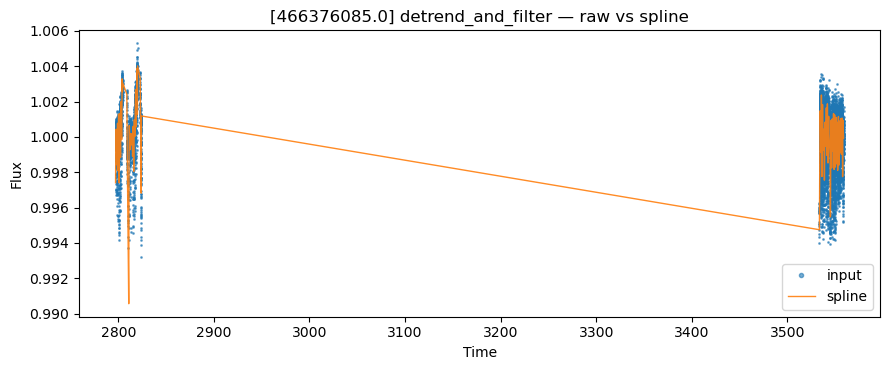

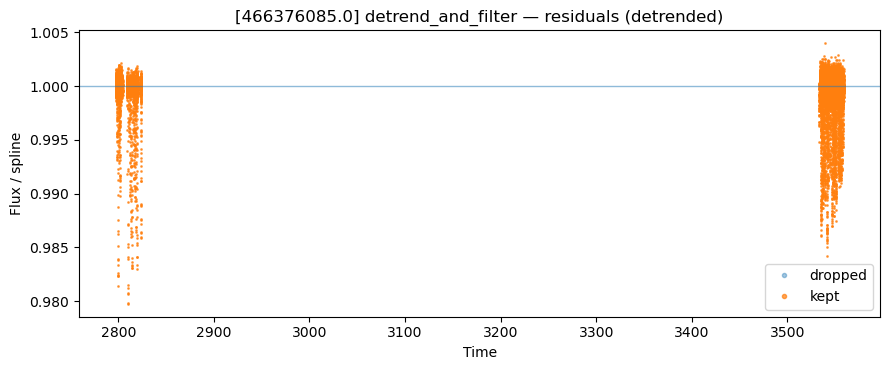

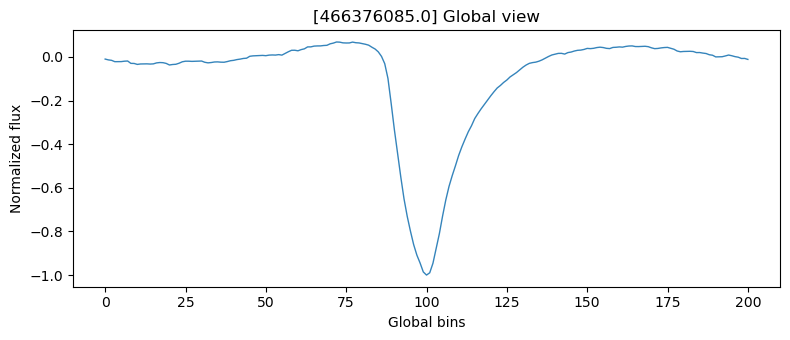

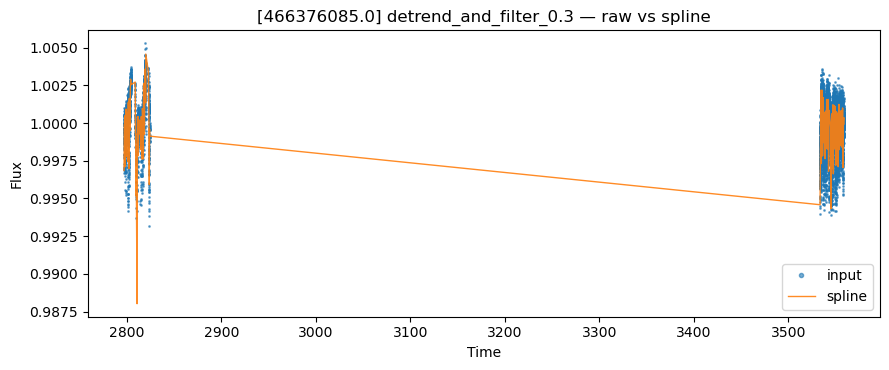

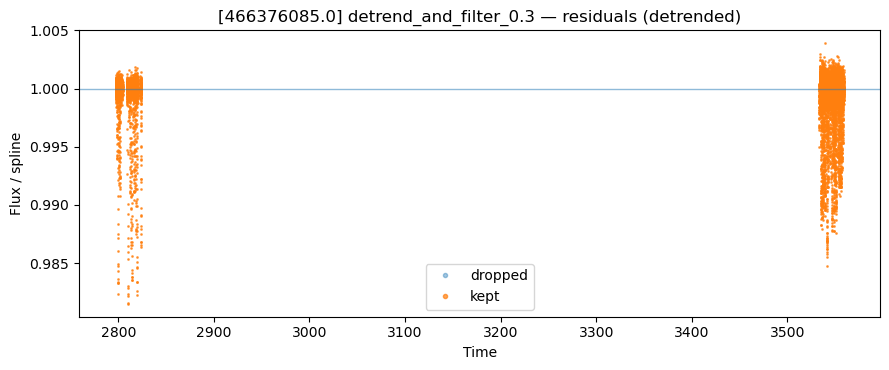

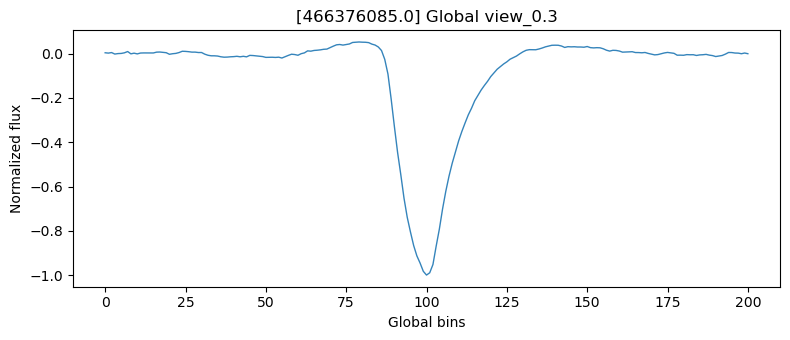

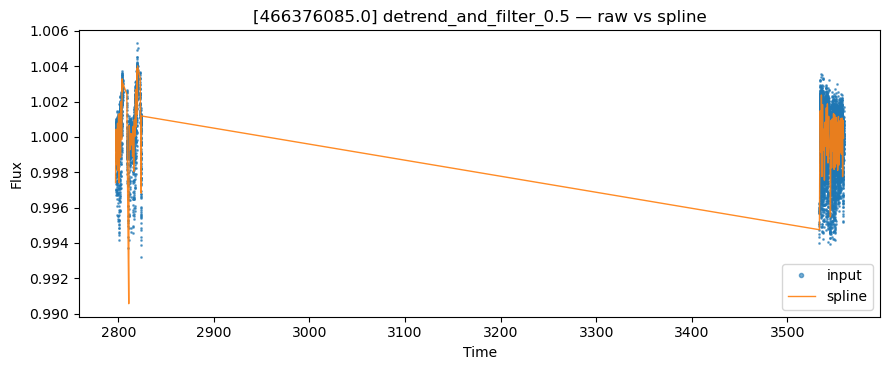

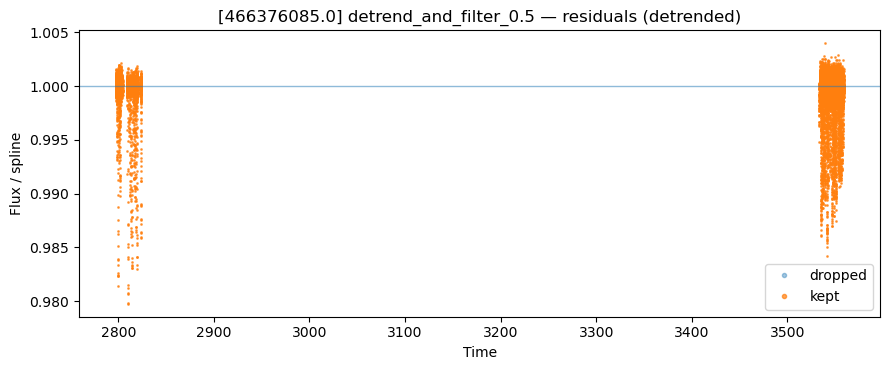

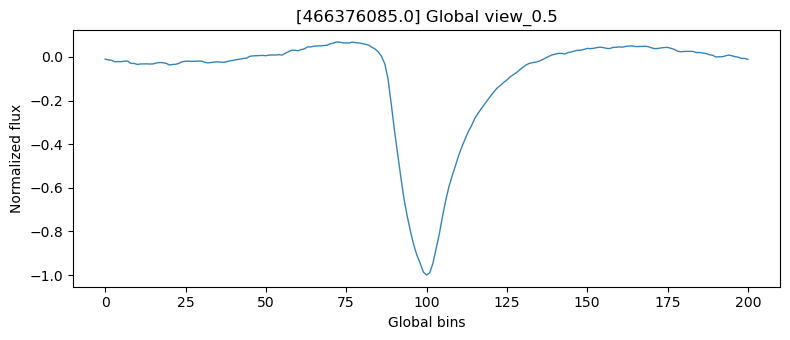

{'_none': array([594,  16, 587, ..., 582, 591, 584]),
 '_0.3': array([594,  16, 587, ..., 582, 591, 584]),
 '_0.5': array([594,  16, 587, ..., 582, 591, 584])}

In [30]:
# Step 2: Generate standard views
from astronet.preprocess.preprocess import filter_outliers, get_spline_mask
from light_curve_util import keplersplinev2


def detrend_and_filter_debug(
    tic_id, time, flux, period, epoch, duration, fixed_bkspace,
    *,
    plot=True,
    title_tag=""
):
    # 1) Build transit mask (in-transit = True)
    input_mask = get_spline_mask(time, period, epoch, duration)
    # 2) Fit spline
    spline_flux, metadata = keplersplinev2.choosekeplersplinev2(
        time,
        flux,
        input_mask=input_mask,
        fixed_bkspace=fixed_bkspace,
        return_metadata=True
    )

    detrended_flux = flux / spline_flux

    # 3) Outlier filtering (keep the mask aligned with filtered arrays)
    detr_time, detr_flux, keep_mask = filter_outliers(time, detrended_flux, input_mask)

    # 4) Plot debug views
    if plot:
        tag = "" if fixed_bkspace is None else f"_{fixed_bkspace}"
        title = f"[{tic_id}] detrend_and_filter{tag}{title_tag}"

        # (a) Raw + spline
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[input_mask], flux[input_mask], ".", markersize=2, alpha=0.6, label="input")
        plt.plot(time, spline_flux, "-", linewidth=1.0, alpha=0.9, label="spline")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.title(f"{title} — raw vs spline")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.show()

        # (b) Residuals / detrended, highlighting points dropped by outlier filter
        kept = np.isin(time, detr_time)
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[~kept], detrended_flux[~kept], ".", markersize=2, alpha=0.4, label="dropped")
        plt.plot(time[kept],   detrended_flux[kept],   ".", markersize=2, alpha=0.7, label="kept")
        plt.axhline(1.0, lw=1, alpha=0.5)
        plt.xlabel("Time")
        plt.ylabel("Flux / spline")
        plt.title(f"{title} — residuals (detrended)")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.show()

    return detr_time, detr_flux, input_mask[np.isin(time, detr_time)]

def _debug_plot_global_view(tic, view, tag=""):
    plt.figure(figsize=(8, 3.5))
    x = np.arange(len(view))
    plt.plot(x, view, "-", linewidth=1.0, alpha=0.9)
    plt.xlabel("Global bins")
    plt.ylabel("Normalized flux")
    plt.title(f"[{tic}] Global view{tag}")
    plt.tight_layout()
    plt.show()

def build_global_views_with_debug(
    tic,
    time,
    flux,
    period,
    epoc,
    duration,
    bkspaces=(None, 0.3, 0.5),
):
    """
    Minimal pipeline:
      - detrend_and_filter
      - phase_fold_and_sort_light_curve
      - global_view
    Plus debug visualizations at each of the three steps.
    Returns: dict mapping tag -> fold_num (from the folded call).
    """
    fold_nums_out = {}

    for bkspace in bkspaces:
        tag = "" if bkspace is None else f"_{bkspace}"

        # 1) Detrend + filter
        detrended_time, detrended_flux, transit_mask = detrend_and_filter_debug(
            tic, time, flux, period, epoc, duration, bkspace
        )

        # 2) Phase-fold + sort
        folded_time, folded_flux, fold_num, tr_mask = preprocess.phase_fold_and_sort_light_curve(
            detrended_time, detrended_flux, transit_mask, period, epoc
        )
        fold_nums_out[tag or "_none"] = fold_num

        # 3) Global view on folded data
        view, std, mask, _, _ = preprocess.global_view(tic, folded_time, folded_flux, period)

        # Debug viz #3
        _debug_plot_global_view(tic, view, tag=tag)

    return fold_nums_out

print(dir(tce))

time_a, flux_a = get_lightcurve(astro_id=astro_id_to_inspect, location=DIR_A + '/' + FILE)
time_b, flux_b = get_lightcurve(astro_id=astro_id_to_inspect, location=DIR_A + '/' + FILE)
build_global_views_with_debug(tce['TIC ID'],  time_a, flux_a, tce.Per, tce.Epoc, tce.Dur)
#
#build_global_views_with_debug(tce['TIC ID'],  time_b, flux_b, tce.Per, tce.Epoc, tce.Dur)
